我们将从零开始实现整个方法，包括数据流水线、模型、损失函数和小批量随机梯度下降优化器

In [2]:
%pip install matplotlib#%是指在jupyter里对应的环境里安装，是jupyter的魔法语句

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------- ------------------------- 3.4/9.3 MB 20.2 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 34.3 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 48.4 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- ----------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [4]:
import random
import torch

根据带有噪声的线性模型构造一个人造数据集。我们使用线性模型参数w=[2,-3.4].T、b=4.2和噪声项生成数据集及其标签：y=Xw+b+噪声

In [5]:
def synthetic_data(w,b,num_examples):
    X=torch.normal(0,1,(num_examples,len(w)))#随机生成一组均值为0，标准差为1的x，其中行数为num_examples，列数为len(w)
    y=torch.matmul(X,w)+b#矩阵乘法
    y+=torch.normal(0,0.01,y.shape)#按照y的形状添加N(0,0.01)的噪声
    return X,y.reshape(-1,1)#-1的意思是让pytorch自动计算，因为后面固定为1列

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)#赋予特征值和标签

features中的每一行都包含一个二维数据样本，labels中的每一行都包含一维标签值

In [6]:
print('features:',features[0],'\nlabels:',labels[0])

features: tensor([0.5699, 0.7607]) 
labels: tensor([2.7732])


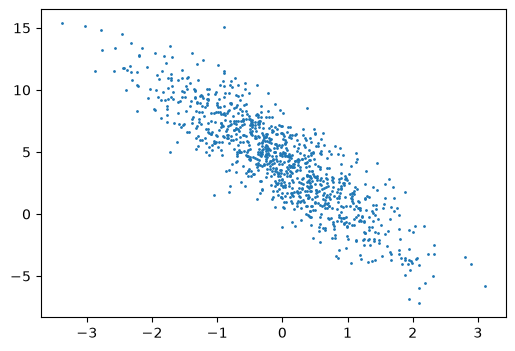

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(features[:,(1)].detach().numpy(),
            labels.detach().numpy(),s=1)#x轴为x2的特征值；y轴为标签值，点的大小为1；先将张量detach为标量，然后进行numpy的转换，方便后续的matplotlib作图
plt.show()

定义一个data_iter函数，该函数接受批量大小、特征矩阵和标签向量作为输入，生成大小为batch_size的小批量

In [8]:
def data_iter(batch_size,features,labels):#函数的目的：进行size大小的小批次训练
    num_examples=len(features)
    indices=list(range(num_examples))#就是对样本的编号，index的复数
    #这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)#把样本编号打乱
    for i in range(0,num_examples,batch_size):#进行100次
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])#min防止最后一批超出范围，最后会全遍历完
        yield features[batch_indices],labels[batch_indices]#交出这些选中数据，如果用return第一次返回就结束了
batch_size=10
for X,y in data_iter(batch_size,features,labels):#这里一共100次，因为太多了，我们就输出一次
    print(X,'\n',y)
    break

tensor([[-0.6782,  0.9341],
        [-0.8509, -0.9760],
        [ 0.2103, -0.0060],
        [-0.2040,  0.4447],
        [-0.1144,  1.2236],
        [ 0.8142, -0.4748],
        [-0.4667, -0.0974],
        [ 1.0894, -1.0237],
        [ 1.0717, -0.9017],
        [-0.3044,  1.1374]]) 
 tensor([[-0.3337],
        [ 5.8189],
        [ 4.6432],
        [ 2.2813],
        [-0.1950],
        [ 7.4653],
        [ 3.5899],
        [ 9.8651],
        [ 9.4190],
        [-0.2715]])


定义初始化模型参数

In [9]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)#我们不能告诉模型true_w，所以给他随机赋予一个合理的起点
b=torch.zeros(1,requires_grad=True)

定义模型

In [10]:
def linreg(X,w,b):
    return torch.matmul(X,w)+b

定义损失函数：均方误差

In [11]:
def squared_loss(y_hat,y):#y_hat为预测值，y为真实值
    return (y_hat-y.reshape(y_hat.shape))**2/2

定义优化算法:小批量随机梯度下降

In [12]:
def sgd(params,lr,batch_size):
    with torch.no_grad():#下列操作不要记录到pytorch的计算图中
        for param in params:#取出参数，第一次是w，第二次是b
            param-=lr*param.grad/batch_size#梯度下降，一个batch中有很多样本，我们进行梯度下降会对他们进行累加，所以除以size得到平均梯度
            param.grad.zero_()#清0

训练过程

In [16]:
lr=0.03
num_epochs=3
net=linreg
loss=squared_loss
for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)#预测y和真实y
        l.sum().backward()
        sgd([w,b],lr,batch_size)
    with torch.no_grad():#做一下评估
        train_l=loss(net(features,w,b),labels)
        print(f'epoch{epoch+1},loss{float(train_l.mean())}')#f'...'表示这是一个格式化字符串
    

epoch1,loss0.03905109316110611
epoch2,loss0.0001475438621127978
epoch3,loss4.922446532873437e-05


比较真实参数和通过训练学到的参数来评估训练的成功程度

In [19]:
print(f'w的估计误差:{true_w-w.reshape(true_w.shape)}')
print(f'b的估计误差:{true_b-b}')

w的估计误差:tensor([ 0.0009, -0.0006], grad_fn=<SubBackward0>)
b的估计误差:tensor([0.0006], grad_fn=<RsubBackward1>)


可以修改训练过程的超参数，得到不同结果